In [61]:
# SET PYTHONPATH to the parent directory 
import sys
import numpy as np
import os
sys.path.append(os.path.abspath(".."))

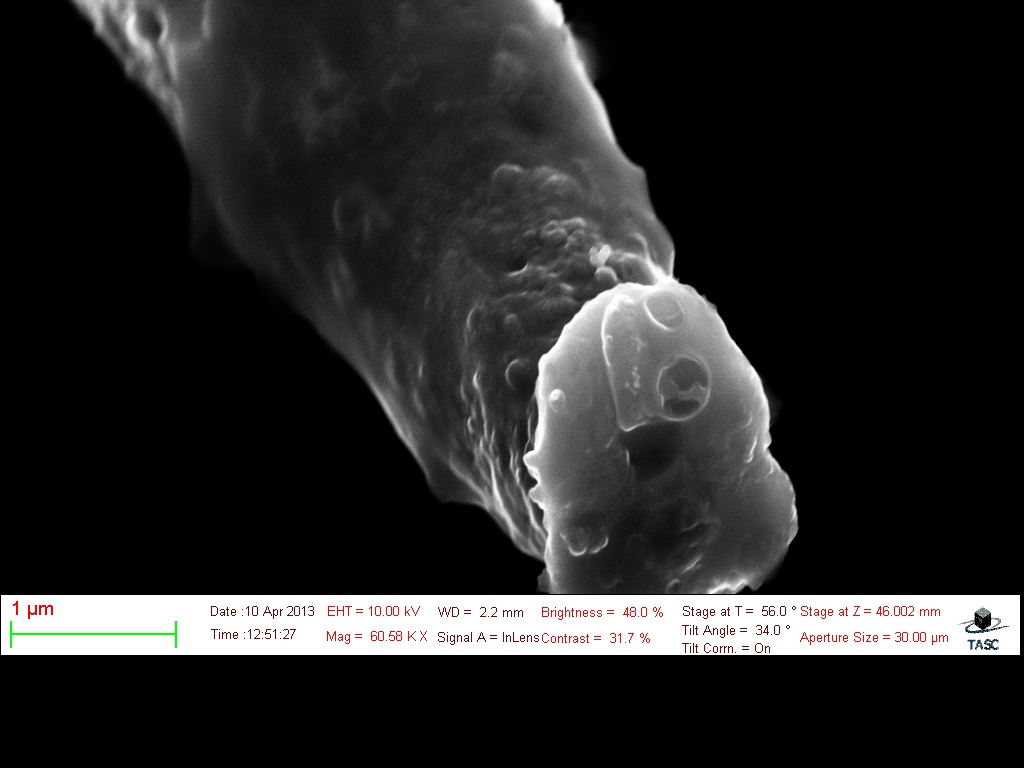

In [62]:

from PIL import Image,ImageDraw
path = "/Users/karella/Downloads/Katelyn/raw/Tips/L5_297a2bff0108f423d605658119f314e7.jpg"
img = Image.open(path)
img

In [63]:
def unique_colors_per_row_axis(image_path):
    img = Image.open(image_path).convert("RGB")
    arr = np.asarray(img, dtype=np.uint8)   # shape (H, W, 3)

    H, W, C = arr.shape
    results = []

    maximum = 0 
    maximum_idx = -1
    for i in range(H):
        col = arr[i]                        # shape (H, 3)
        uniq, counts = np.unique(col, axis=0, return_counts=True)          # shape (k, 3), unique RGBs in this column
        if maximum < counts.max():
            maximum = max(maximum, counts.max())
            maximum_idx = i

        results.append(counts.max())

    return results, maximum_idx, maximum

In [64]:
result, idx, maxi= unique_colors_per_row_axis(path)
result

[493,
 501,
 521,
 521,
 525,
 525,
 524,
 523,
 521,
 518,
 518,
 515,
 514,
 513,
 511,
 511,
 509,
 505,
 506,
 507,
 508,
 508,
 507,
 510,
 509,
 511,
 511,
 512,
 512,
 513,
 512,
 513,
 512,
 513,
 511,
 511,
 511,
 508,
 507,
 509,
 507,
 507,
 509,
 509,
 510,
 512,
 514,
 511,
 516,
 515,
 513,
 514,
 514,
 515,
 515,
 515,
 518,
 516,
 518,
 518,
 519,
 519,
 518,
 522,
 522,
 523,
 526,
 526,
 528,
 529,
 529,
 529,
 533,
 532,
 532,
 535,
 535,
 537,
 540,
 542,
 545,
 547,
 548,
 550,
 551,
 551,
 557,
 554,
 555,
 555,
 555,
 556,
 558,
 558,
 559,
 557,
 557,
 560,
 557,
 560,
 561,
 560,
 561,
 564,
 563,
 564,
 563,
 565,
 566,
 566,
 568,
 567,
 568,
 568,
 568,
 569,
 568,
 568,
 570,
 571,
 570,
 571,
 571,
 572,
 571,
 571,
 573,
 573,
 570,
 573,
 574,
 574,
 572,
 574,
 573,
 574,
 572,
 575,
 574,
 575,
 576,
 575,
 576,
 576,
 575,
 575,
 575,
 576,
 576,
 576,
 576,
 575,
 575,
 574,
 573,
 573,
 574,
 573,
 571,
 570,
 571,
 569,
 567,
 566,
 564,
 561,
 561

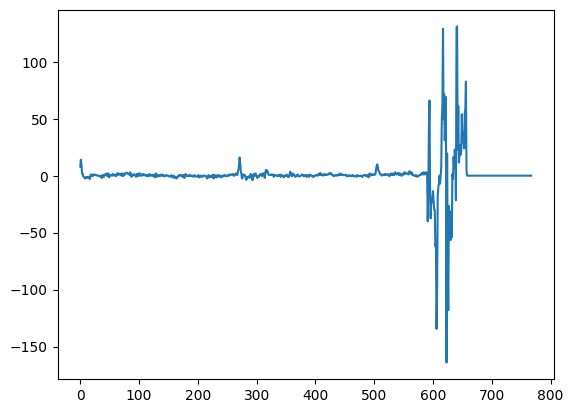

In [65]:
import matplotlib.pyplot as plt
# convolution with derivative
grad = np.gradient(result)
plt.plot(grad, label='Gradient')



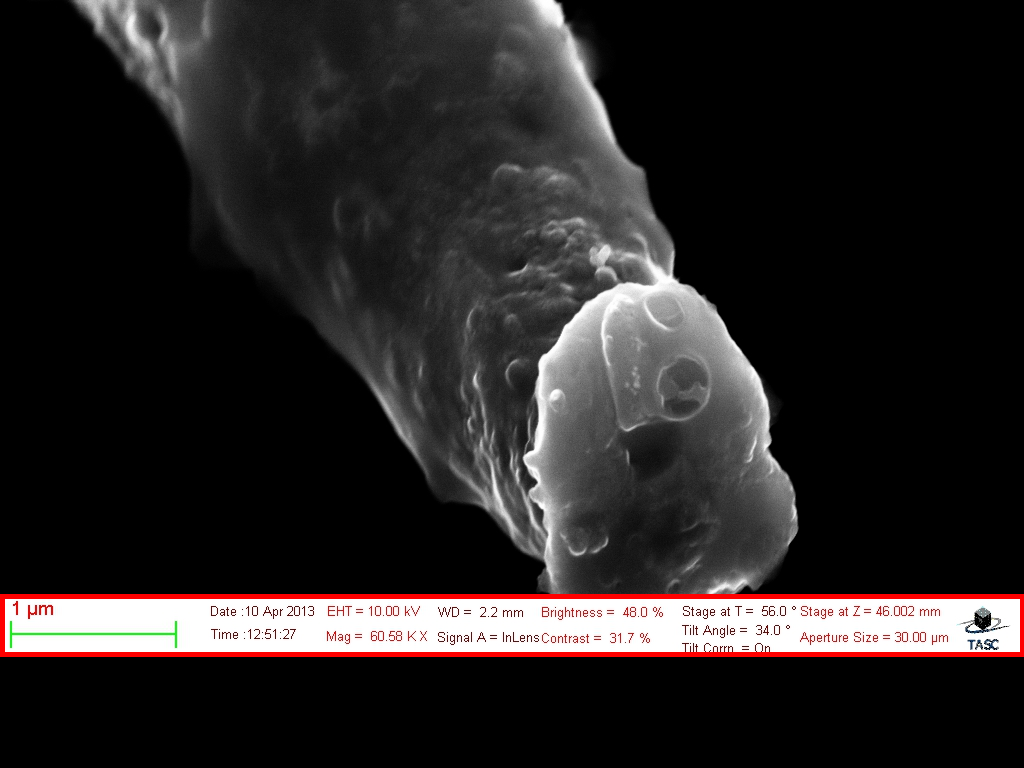

In [ ]:

grad = np.argwhere(grad > 5)
row_start, row_end = np.min(grad), np.max(grad)
# draw rectangle in the original image
img_np = np.array(img)
mask = np.ones_like(img_np[..., 0]) 
mask[row_start:row_end, :] = 0
draw = ImageDraw.Draw(img)
draw.rectangle([0, row_start, img.width, row_end], outline="red", width=5)
img

In [14]:
def unique_colors_per_row_axis(arr):

    H, W, C = arr.shape
    results = []
    maximum = -1 
    maximum_idx = -1
    for i in range(H):
        col = arr[i]                        # shape (H, 3)
        uniq, counts = np.unique(col, axis=0, return_counts=True)          # shape (k, 3), unique RGBs in this column
        if maximum < counts.max():
            maximum = max(maximum, counts.max())
            maximum_idx = i

        results.append(counts.max())

    return results, maximum_idx, maximum

def get_mask(img_path):
    threshold = 150
    img = Image.open(img_path).convert("RGB")
    img = np.asarray(img, dtype=np.uint8)   # shape (H, W, 3)
    result, idx, maxi = unique_colors_per_row_axis(img)
    grad = np.gradient(result)
    row_start, row_end = np.argmax(grad), np.argmin(grad)
    # All below start mask
    if threshold < np.max(grad):
        return img[:row_start], img[row_start:row_end], img[row_end:]
    else: 
        return img, None, None

img, label, rest = get_mask(path)


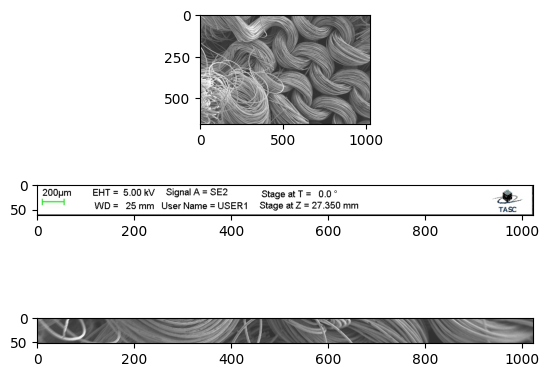

In [15]:
# Plot all and keep resolution 
plt.subplot(3, 1, 1)
plt.imshow(img)
plt.subplot(3, 1, 2)
plt.imshow(label)
plt.subplot(3, 1, 3)
plt.imshow(rest)


In [19]:
import tqdm
output_dir = os.path.join("/Users/karella/Downloads/Katelyn/masked")
input_dir = "/Users/karella/Downloads/Katelyn/raw"
os.makedirs(output_dir, exist_ok=True)

input_dirs = os.listdir(input_dir)
input_dirs = [d for d in input_dirs if "tips" not in d]

for dir in tqdm.tqdm(input_dirs, desc="Processing directories", unit="dir", leave=False):
    if dir[0] == '.':
        continue
    # Make subdir
    if not os.path.exists(os.path.join(output_dir, dir)):
        os.makedirs(os.path.join(output_dir, dir), exist_ok=True)
    else: 
        continue
    for file in tqdm.tqdm(os.listdir(os.path.join(input_dir, dir)), desc="Processing files", unit="file", leave=False):
        if file[0] == '.':
            continue
        # Mask the dir
        img, _, _ = get_mask(os.path.join(input_dir, dir, file))
        plt.imsave(os.path.join(output_dir, dir, file), img)

In [ ]:
shape = None
for file in tqdm.tqdm(os.listdir(os.path.join(input_dir, "Tips")), desc="Processing files", unit="file", leave=False):
        if file[0] == '.':
            continue
        # Mask the dir
        img_path = os.path.join(input_dir, "Tips", file)
        img = Image.open(img_path).convert("RGB").crop((0, 0, img.size[0], 630))
        img = np.asarray(img, dtype=np.uint8)   # shape (H, W, 3)
        plt.imsave(os.path.join(output_dir, "Tips", file), img)

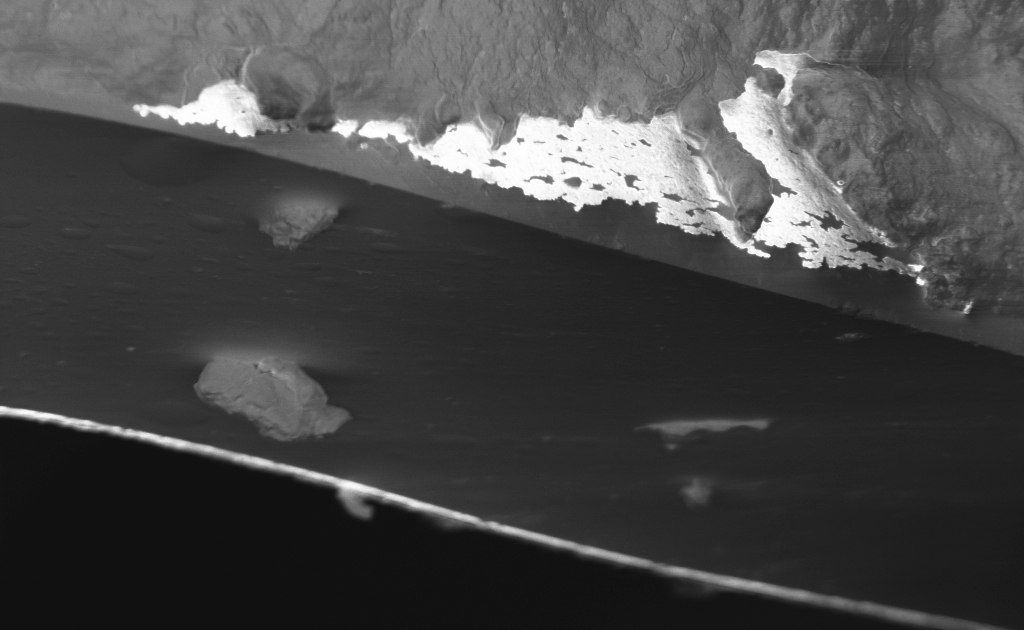

In [ ]:
img.crop((0, 0, img.size[0], 630))

In [ ]:
path1 = "L5_1f920925c29e92f22e4b282cf18d3486.jpg"
path2 = "L9_2f7c0bdeb5d59ca41a3786400997ce99.jpg"
img = Image.open(os.path.join(output_dir, "Fibres", path2))
# Show just hue
hue = img.convert("HSV").getchannel("H")
# Get all the hue futher than 5 from zero, hue is circle
hue = np.array(hue)

68

In [53]:
# filter images that contains some color 
import shutil
colored_dir = os.path.join("/Users/karella/Downloads/Katelyn/color/")
no_colored_dir = os.path.join("/Users/karella/Downloads/Katelyn/no_color/")
os.makedirs(colored_dir, exist_ok=True)
os.makedirs(no_colored_dir, exist_ok=True)

for file in tqdm.tqdm(os.listdir(os.path.join(output_dir, "Tips")), desc="Processing files", unit="file", leave=False):
            # Mask the dir
        img_path = os.path.join(output_dir, "Tips", file)
        img = Image.open(img_path).convert("RGB")
        hue = np.array(img.convert("HSV").getchannel("H"))
        if np.max(hue) == 0: 
            shutil.copy(img_path, no_colored_dir)
        else:
            shutil.copy(img_path, colored_dir)


In [71]:
output_dirs = os.listdir(output_dir)
for dir in tqdm.tqdm(output_dirs, desc="Processing directories", unit="dir", leave=False):
    if dir[0] == '.':
        continue
    # Make subdir
    if not os.path.exists(os.path.join(colored_dir, dir)):
        os.makedirs(os.path.join(colored_dir, dir), exist_ok=True)
    else: 
        continue
    os.makedirs(os.path.join(no_colored_dir, dir), exist_ok=True)

    for file in tqdm.tqdm(os.listdir(os.path.join(output_dir, dir)), desc="Processing files", unit="file", leave=False):
        if file[0] == '.':
            continue
        # Move the colored images
        img_path = os.path.join(output_dir, dir, file)
        img = Image.open(img_path).convert("RGB")
        hue = np.array(img.convert("HSV").getchannel("H"))
        if np.max(hue) == 0: 
            shutil.copy(img_path, os.path.join(no_colored_dir, dir))
        else:
            shutil.copy(img_path, os.path.join(colored_dir, dir))


In [69]:
os.path.join(output_dir, dir)

'/Users/karella/Downloads/Katelyn/masked/s'